Overall population over ticks:

Total Runs Found in DB: 1
Analysing Run ID: 1
Total ticks recorded in this run: 152
The population at the end of Run 1 was 457


,id,run_id,tick_number,timestamp,population
0,1,1,1,2026-04-07T22:45:42.392149,200
1,2,1,2,2026-04-07T22:45:42.659550,200
2,3,1,3,2026-04-07T22:45:42.934007,200
3,4,1,4,2026-04-07T22:45:43.212326,200
4,5,1,5,2026-04-07T22:45:43.484634,200


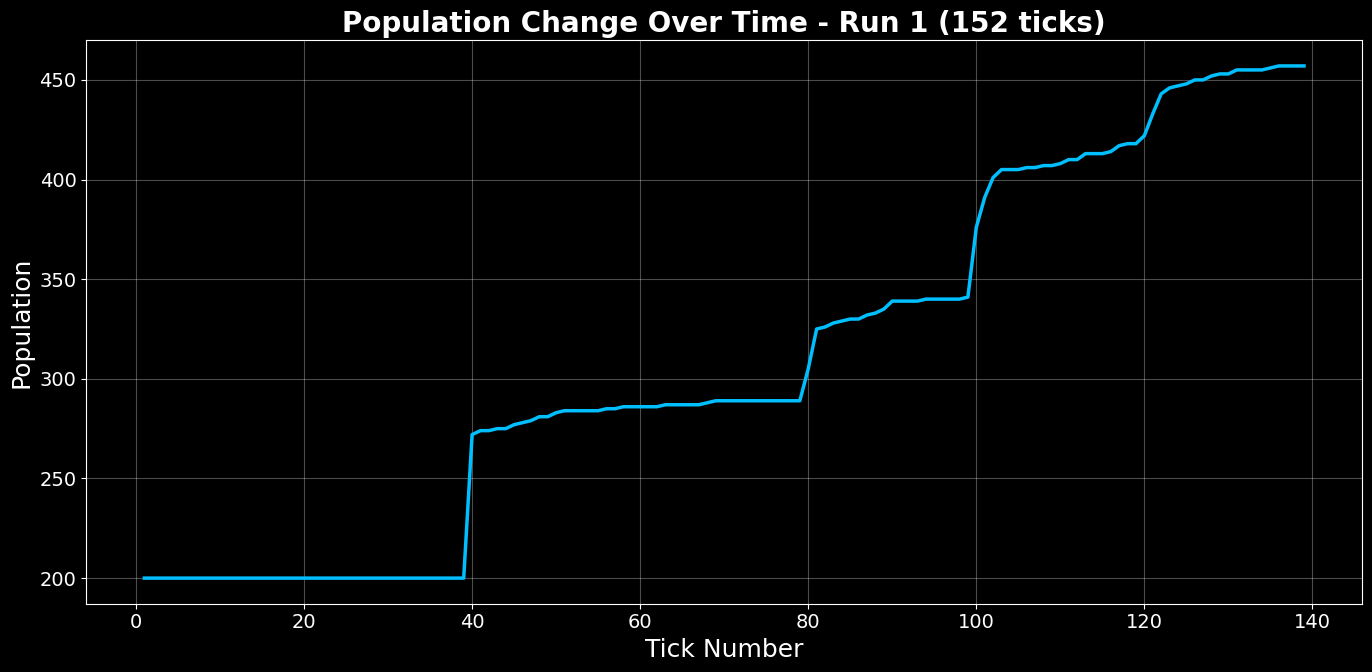

Male/female population columns not found in ticks table. Skipping gender split plot.

--- Population Statistics for Run 1 ---
Total Ticks Plotted: 152
Starting Population: 200
Ending Population: 457
Maximum Population: 457
Minimum Population: 200
Average Population: 309.33
Population Change: 257


In [6]:
# --- CONFIGURATION ---
# Change this number to 1, 2, or whatever run you want to see
target_run_id = 1
# ---------------------

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Set up dark theme and larger fonts for poster visibility
plt.style.use('dark_background')
plt.rcParams.update({
    'font.size': 16,
    'axes.labelsize': 18,
    'axes.titlesize': 20,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
    'figure.titlesize': 22
})

# Set pandas display options to handle larger datasets
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Connect to the database
conn = sqlite3.connect("data/ecosystem.db")

# 1. Get all runs to verify the ID exists
runs_df = pd.read_sql_query("SELECT * FROM runs", conn)
print(f"Total Runs Found in DB: {len(runs_df)}")

# 2. Check if your target_run_id is valid
if target_run_id in runs_df['id'].values:
    print(f"Analysing Run ID: {target_run_id}")

    # 3. Load the Ticks for that specific run
    query = f"SELECT * FROM ticks WHERE run_id = {target_run_id} ORDER BY tick_number"
    ticks_df = pd.read_sql_query(query, conn)

    if not ticks_df.empty:
        print(f"Total ticks recorded in this run: {len(ticks_df)}")

        # 4. Get the population from the last recorded tick
        current_pop = ticks_df['population'].iloc[-1]
        print(f"The population at the end of Run {target_run_id} was {current_pop}")

        # 5. Show the first few rows
        display(ticks_df.head())

        # 6. Create a graph of population change over time (optimized for large datasets)
        num_ticks = len(ticks_df)
        fig_width = max(14, num_ticks / 50)  # Wider for larger datasets

        plt.figure(figsize=(fig_width, 7))
        plt.plot(ticks_df['tick_number'], ticks_df['population'], linewidth=2.5, color='#00BFFF', rasterized=True)
        plt.xlabel('Tick Number', fontsize=18)
        plt.ylabel('Population', fontsize=18)
        plt.title(f'Population Change Over Time - Run {target_run_id} ({num_ticks} ticks)', fontsize=20, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        # 7. Plot male and female population over ticks if available
        gender_columns = [
            ('male_population', 'female_population'),
            ('males', 'females'),
            ('male_count', 'female_count'),
            ('num_males', 'num_females'),
            ('male', 'female'),
            ('male_pop', 'female_pop'),
        ]

        male_col = None
        female_col = None
        for m_col, f_col in gender_columns:
            if m_col in ticks_df.columns and f_col in ticks_df.columns:
                male_col = m_col
                female_col = f_col
                break

        if male_col and female_col:
            plt.figure(figsize=(fig_width, 7))
            plt.plot(ticks_df['tick_number'], ticks_df[male_col], label='Males', color='#1f77b4', linewidth=2.5)
            plt.plot(ticks_df['tick_number'], ticks_df[female_col], label='Females', color='#e377c2', linewidth=2.5)
            plt.xlabel('Tick Number', fontsize=18)
            plt.ylabel('Population', fontsize=18)
            plt.title(f'Male vs Female Population Over Time - Run {target_run_id}', fontsize=20, fontweight='bold')
            plt.legend(fontsize=16)
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            print('Male/female population columns not found in ticks table. Skipping gender split plot.')

        # Print summary statistics
        print(f"\n--- Population Statistics for Run {target_run_id} ---")
        print(f"Total Ticks Plotted: {num_ticks}")
        print(f"Starting Population: {ticks_df['population'].iloc[0]}")
        print(f"Ending Population: {ticks_df['population'].iloc[-1]}")
        print(f"Maximum Population: {ticks_df['population'].max()}")
        print(f"Minimum Population: {ticks_df['population'].min()}")
        print(f"Average Population: {ticks_df['population'].mean():.2f}")
        print(f"Population Change: {ticks_df['population'].iloc[-1] - ticks_df['population'].iloc[0]}")
    else:
        print(f"No ticks found for Run ID: {target_run_id}")
else:
    print(f"Error: Run ID {target_run_id} does not exist in the database. Please choose a valid ID.")


male/female population over ticks:

AttributeError: 'Text' object has no property 'fontsTrueSize'

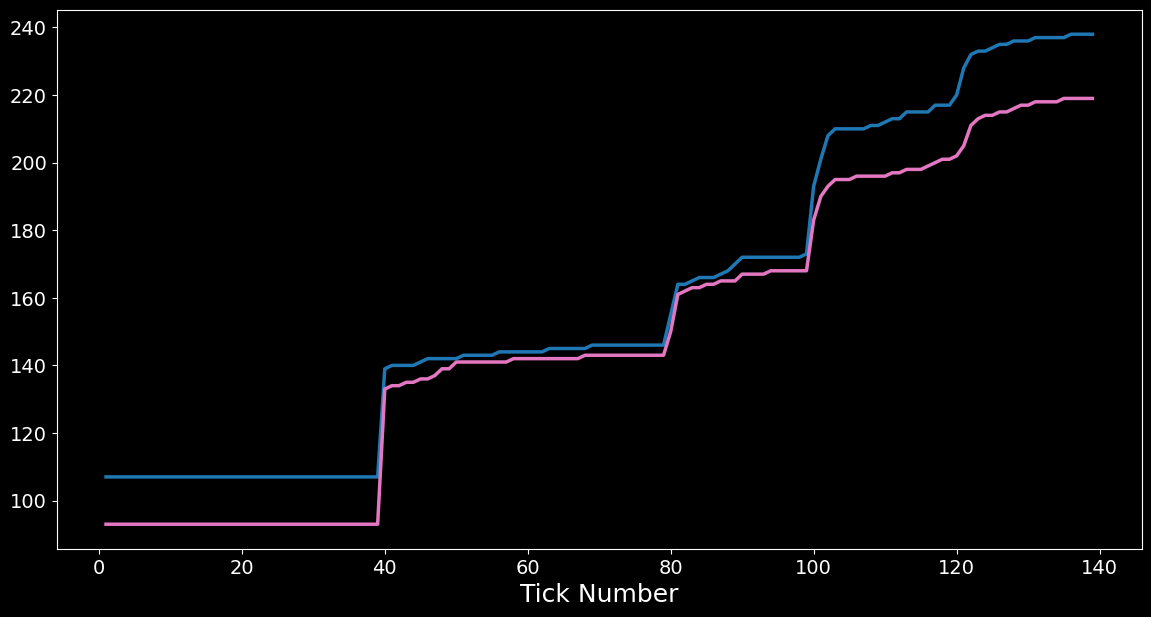

In [ ]:
# Separate plot cell for male/female population over ticks
# The ticks table only stores total population, so we derive sex counts from creature_states.
# Some runs contain duplicated tick_number values after resuming, which can artificially inflate counts.

# Apply dark theme and larger fonts for poster visibility
plt.style.use('dark_background')
plt.rcParams.update({
    'font.size': 16,
    'axes.labelsize': 18,
    'axes.titlesize': 20,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
    'figure.titlesize': 22
})

query = '''
SELECT t.tick_number,
       cs.sex,
       COUNT(*) AS count
FROM creature_states cs
JOIN (
    SELECT tick_number, MAX(id) AS id
    FROM ticks
    WHERE run_id = ?
    GROUP BY tick_number
) t ON cs.tick_id = t.id
GROUP BY t.tick_number, cs.sex
ORDER BY t.tick_number, cs.sex
'''
gender_df = pd.read_sql_query(query, conn, params=(target_run_id,))

if gender_df.empty:
    print('No creature sex data found for this run. The ticks table only stores total population.')
else:
    pivot_df = gender_df.pivot(index='tick_number', columns='sex', values='count').fillna(0)
    pivot_df = pivot_df.rename(columns={
        'M': 'Males',
        'F': 'Females',
    })

    plt.figure(figsize=(max(14, len(pivot_df) / 50), 7))
    if 'Males' in pivot_df.columns:
        plt.plot(pivot_df.index, pivot_df['Males'], label='Males', color='#1f77b4', linewidth=2.5)
    if 'Females' in pivot_df.columns:
        plt.plot(pivot_df.index, pivot_df['Females'], label='Females', color='#e377c2', linewidth=2.5)

    plt.xlabel('Tick Number', fontsize=18)
    plt.ylabel('Creature Count', fontsize=18)
    plt.title(f'Male vs Female Population Over Time - Run {target_run_id}', fontsize=20, fontweight='bold')
    plt.legend(fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


Age distribution graph for males and females at the latest tick snapshot:

In [ ]:
import seaborn as sns

# 1. Configuration
# target_run_id should be defined in your first cell
# conn should be your active sqlite3 connection

# 2. Optimized Query using your specific column names: pos_x, pos_y
query = '''
SELECT cs.pos_x, cs.pos_y 
FROM creature_states cs
JOIN ticks t ON cs.tick_id = t.id
WHERE t.run_id = ? 
  AND t.tick_number = (SELECT MAX(tick_number) FROM ticks WHERE run_id = ?)
  AND cs.alive = 1
'''

try:
    pos_df = pd.read_sql_query(query, conn, params=(target_run_id, target_run_id))

    if not pos_df.empty:
        # 3. Create the Density Plot
        plt.figure(figsize=(12, 10))
        
        # 'mako' or 'viridis' look great on dark backgrounds
        # fill=True creates the solid "heat" effect
        sns.kdeplot(
            data=pos_df, x='pos_x', y='pos_y', 
            fill=True, 
            thresh=0, 
            levels=100, 
            cmap='mako',
            cbar=True,
            cbar_kws={'label': 'Creature Density'}
        )

        # 4. Styling
        plt.title(f'Final Tick Concentration Heatmap (Run {target_run_id})', fontsize=20, pad=20)
        plt.xlabel('World X Coordinate', fontsize=14)
        plt.ylabel('World Y Coordinate', fontsize=14)
        
        # Adjust these limits based on your Godot world size
        plt.xlim(pos_df['pos_x'].min() - 10, pos_df['pos_y'].max() + 10) 
        plt.ylim(pos_df['pos_y'].min() - 10, pos_df['pos_y'].max() + 10)

        plt.tight_layout()
        plt.show()
    else:
        print(f"No living creatures found at the end of Run {target_run_id} to map.")

except Exception as e:
    print(f"Error generating heatmap: {e}")

No living creatures found at the end of Run 2 to map.
